Title: RL_data_analysis_NM_cc_fut_comp.ipynb

Purpose: Compare the components of current climate and future climate

Author: Onno Nennecke on 17.04.2025 Modified: 01.04.2026

Input data: 

- Adjusted Model output: model_output_all.nc
    - This file lies here: '/climca/people/onennecke/model_output/not_bias_corrected/model_output_all_future.nc'

Output data:

- Some plots
    - These files lie here: /home/onennecke/Code/Figures/

In [11]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
import seaborn as sns

In [12]:
path = '/climca/people/onennecke/model_output/not_bias_corrected/model_output_all_future.nc'
files = [path]

ds = xr.open_dataset(path)

ts_datasets = ds.where((ds.ESM_run != 'ERA5_hist_wwd') & (ds.ESM_run != 'SMARD_hist'),drop=True)
ts_datasets.load()

ds_CMIP6 = ds.where((ds.ESM_run != 'ERA5_hist_week') & (ds.ESM_run != 'ERA5_hist_wwd') & (ds.ESM_run != 'SMARD_hist'),drop=True)
ds_CMIP6.load()

# All data
wind_fut = ts_datasets['wind_off_prod'] + ts_datasets['wind_on_prod']
wind_on_fut = ts_datasets['wind_on_prod']
wind_off_fut = ts_datasets['wind_off_prod']
solar_fut = ts_datasets['solar_prod']
total_fut = ts_datasets['total_prod']
demand_fut = ts_datasets['demand']
res_load_fut = ts_datasets['Residual_load']

In [3]:
path = '/climca/people/onennecke/model_output/not_bias_corrected/model_output_all.nc'
files = [path]

ds = xr.open_dataset(path)

ts_datasets_curr_clim = ds.where((ds.ESM_run != 'ERA5_hist_wwd') & (ds.ESM_run != 'SMARD_hist'),drop=True)
ts_datasets_curr_clim.load()

wind_curr_clim = ts_datasets_curr_clim['wind_off_prod'] + ts_datasets_curr_clim['wind_on_prod']
wind_on_curr_clim = ts_datasets_curr_clim['wind_on_prod']
wind_off_curr_clim = ts_datasets_curr_clim['wind_off_prod']
solar_curr_clim = ts_datasets_curr_clim['solar_prod']
total_curr_clim = ts_datasets_curr_clim['total_prod']
demand_curr_clim = ts_datasets_curr_clim['demand']
res_load_curr_clim = ts_datasets_curr_clim['Residual_load']

### Look at max event

In [ ]:
res_load.values.flatten().min()

In [31]:
np.min(res_load_fut)

<xarray.DataArray 'Residual_load' ()> Size: 8B
array(-840.22015769)
Coordinates:
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
    country   float64 8B 9.0
    period    <U4 16B 'week'

In [40]:
ts_datasets_curr_clim['Residual_load'].min()

# Check ESM and date of minimum residual load in current climate
min_res_load_curr_clim = ts_datasets_curr_clim['Residual_load'].min()
ts_datasets_curr_clim.where(ts_datasets_curr_clim['Residual_load'] == min_res_load_curr_clim, drop=True)

<xarray.Dataset> Size: 348B
Dimensions:        (ESM_run: 1, time: 1)
Coordinates:
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
  * time           (time) datetime64[ns] 8B 2019-06-21
    ESM            (ESM_run) <U13 52B 'KACE-1-0-G'
    run            (ESM_run) <U12 48B 'r3i1p1f1'
  * ESM_run        (ESM_run) <U23 92B 'KACE-1-0-G_r3i1p1f1'
    country        float64 8B 9.0
    period         (ESM_run) <U4 16B 'week'
    doy            (time) int64 8B 172
Data variables:
    temp           (ESM_run, time) float64 8B 18.87
    demand         (ESM_run, time) float64 8B 1.324e+03
    sfcWind        (ESM_run, time) float64 8B 11.37
    rsds           (ESM_run, time) float32 4B 342.8
    tas            (ESM_run, time) float32 4B 18.11
    tasmax         (ESM_run, time) float32 4B 22.67
    wind_off_prod  (ESM_run, time) float64 8B 219.0
    wind_on_prod   (ESM_run, time) float64 8B 1.361e+03
    solar_prod     (ESM_run, time) float64 8B 499.7
    total_prod     (ESM_run, time) float64 8B 2.08e+03
    Netto          (ESM_run, time) float64 8B 755.7
    Residual_load  (ESM_run, time) float64 8B -755.7

In [32]:
np.min(res_load_curr_clim)

# Show 10 lowest values of residual load in future and current climate
print("10 lowest values of residual load in future climate:")
print(np.sort(res_load_fut.values.flatten())[:10])
print("\n10 lowest values of residual load in current climate:")
print(np.sort(res_load_curr_clim.values.flatten())[:10])

10 lowest values of residual load in future climate:
[-840.22015769 -790.8243452  -729.13613816 -713.01736561 -706.58786838
 -692.96647934 -680.28831425 -677.60085258 -671.65679693 -669.45723909]

10 lowest values of residual load in current climate:
[-755.7131022  -730.00844451 -672.21003414 -670.18666469 -665.52927655
 -656.0496893  -652.91442176 -652.7093285  -651.18230761 -640.61376592]


In [10]:
ts_datasets_curr_clim.sel(ESM_run = 'EC-Earth3_r121i1p1f1', time = '2019-12-16T00:00:00')

<xarray.Dataset> Size: 348B
Dimensions:        ()
Coordinates:
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
    time           datetime64[ns] 8B 2019-12-16
    ESM            <U13 52B 'EC-Earth3'
    run            <U12 48B 'r121i1p1f1'
    ESM_run        <U23 92B 'EC-Earth3_r121i1p1f1'
    country        float64 8B 9.0
    period         <U4 16B 'week'
    doy            int64 8B 350
Data variables:
    temp           float64 8B -15.46
    demand         float64 8B 1.703e+03
    sfcWind        float64 8B 2.937
    rsds           float32 4B 41.85
    tas            float32 4B -12.98
    tasmax         float32 4B -9.531
    wind_off_prod  float64 8B 9.162
    wind_on_prod   float64 8B 30.18
    solar_prod     float64 8B 80.06
    total_prod     float64 8B 119.4
    Netto          float64 8B -1.583e+03
    Residual_load  float64 8B 1.583e+03

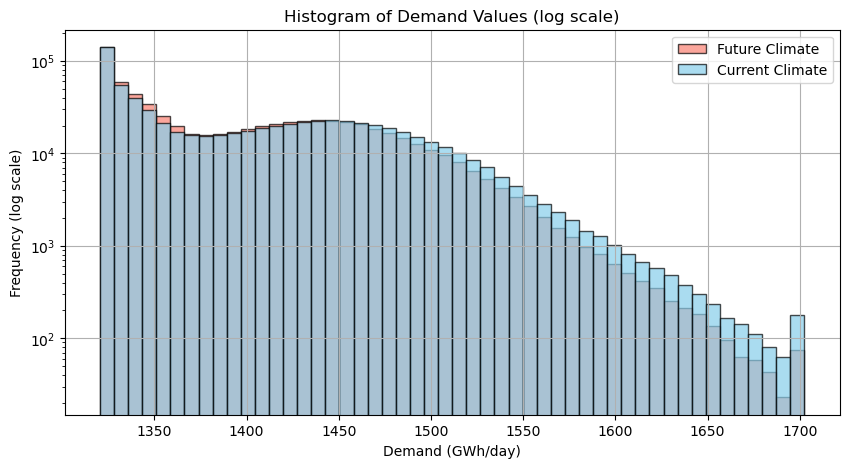

In [33]:
# Compare the distribution of demand values in the future and current climate
plt.figure(figsize=(10, 5))
plt.hist(demand_fut.values.flatten(), bins=50, log=True, color='salmon', edgecolor='black', alpha=0.7, label='Future Climate')
plt.hist(demand_curr_clim.values.flatten(), bins=50, log=True, color='skyblue', edgecolor='black', alpha=0.7, label='Current Climate')
plt.xlabel("Demand (GWh/day)")
plt.ylabel("Frequency (log scale)")
plt.title("Histogram of Demand Values (log scale)")
plt.legend()
plt.grid(True)
plt.show()

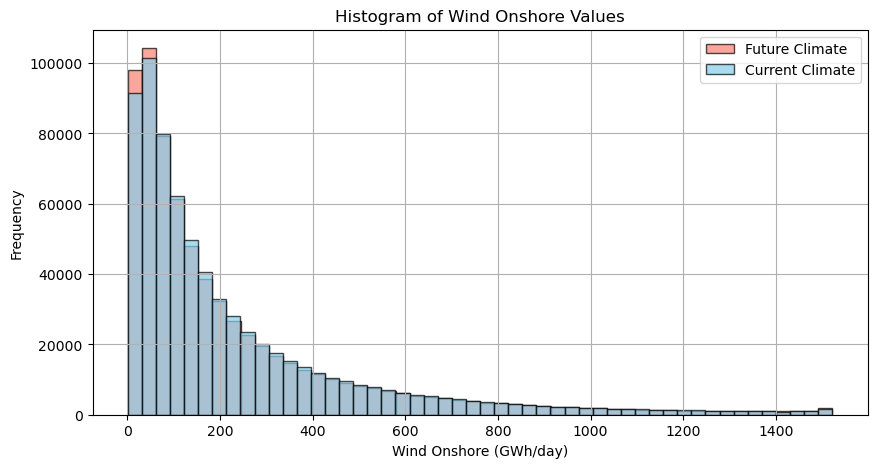

In [25]:
# Compare the distribution of wind onshore values in the future and current climate
plt.figure(figsize=(10, 5))
plt.hist(wind_on_fut.values.flatten(), bins=50, log=False, color='salmon', edgecolor='black', alpha=0.7, label='Future Climate')
plt.hist(wind_on_curr_clim.values.flatten(), bins=50, log=False, color='skyblue', edgecolor='black', alpha=0.7, label='Current Climate')
plt.xlabel("Wind Onshore (GWh/day)")
plt.ylabel("Frequency")
plt.title("Histogram of Wind Onshore Values")
plt.legend()
plt.grid(True)
plt.show()

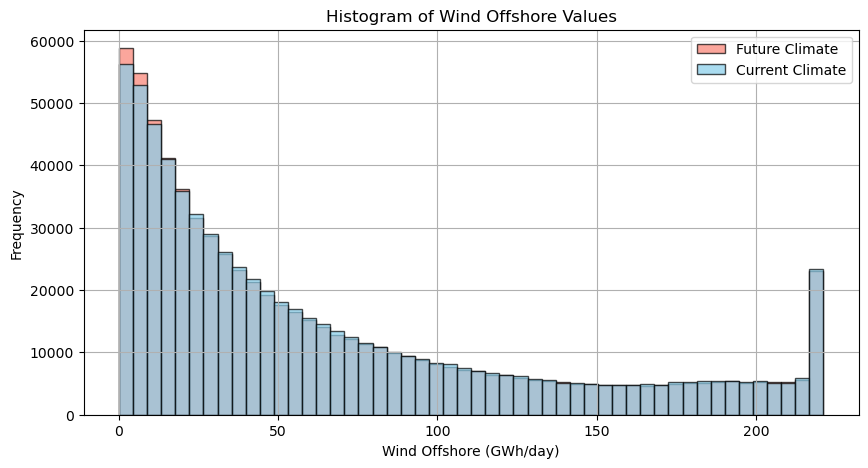

In [26]:
# Compare the distribution of wind offshore values in the future and current climate
plt.figure(figsize=(10, 5))
plt.hist(wind_off_fut.values.flatten(), bins=50, log=False, color='salmon', edgecolor='black', alpha=0.7, label='Future Climate')
plt.hist(wind_off_curr_clim.values.flatten(), bins=50, log=False, color='skyblue', edgecolor='black', alpha=0.7, label='Current Climate')
plt.xlabel("Wind Offshore (GWh/day)")
plt.ylabel("Frequency")
plt.title("Histogram of Wind Offshore Values")
plt.legend()
plt.grid(True)
plt.show()

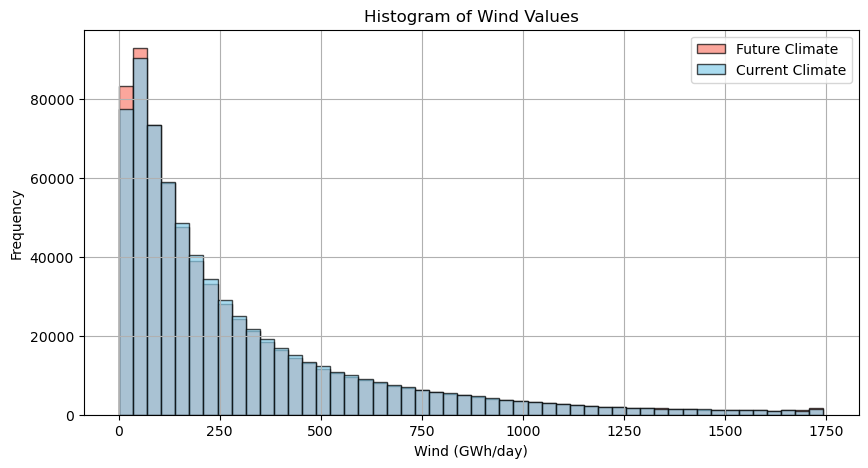

In [27]:
# Compare the distribution of wind values in the future and current climate
plt.figure(figsize=(10, 5))
plt.hist(wind_fut.values.flatten(), bins=50, log=False, color='salmon', edgecolor='black', alpha=0.7, label='Future Climate')
plt.hist(wind_curr_clim.values.flatten(), bins=50, log=False, color='skyblue', edgecolor='black', alpha=0.7, label='Current Climate')
plt.xlabel("Wind (GWh/day)")
plt.ylabel("Frequency")
plt.title("Histogram of Wind Values")
plt.legend()
plt.grid(True)
plt.show()

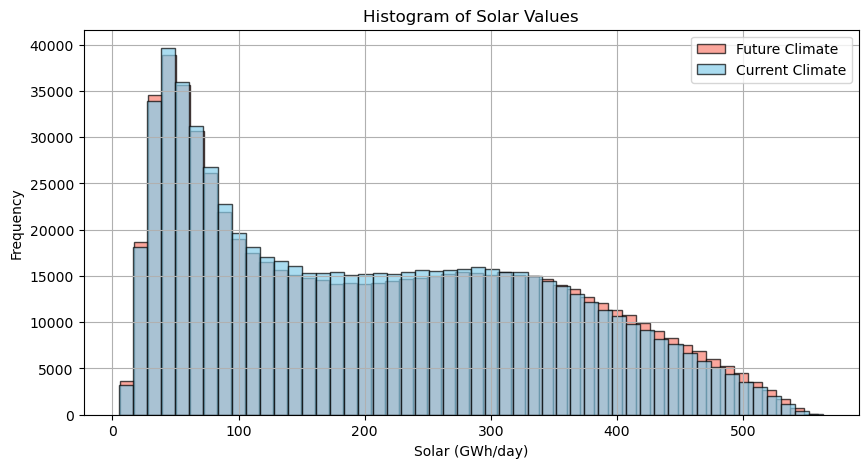

In [28]:
# Compare the distribution of solar values in the future and current climate
plt.figure(figsize=(10, 5))
plt.hist(solar_fut.values.flatten(), bins=50, log=False, color='salmon', edgecolor='black', alpha=0.7, label='Future Climate')
plt.hist(solar_curr_clim.values.flatten(), bins=50, log=False, color='skyblue', edgecolor='black', alpha=0.7, label='Current Climate')
plt.xlabel("Solar (GWh/day)")
plt.ylabel("Frequency")
plt.title("Histogram of Solar Values")
plt.legend()
plt.grid(True)
plt.show()

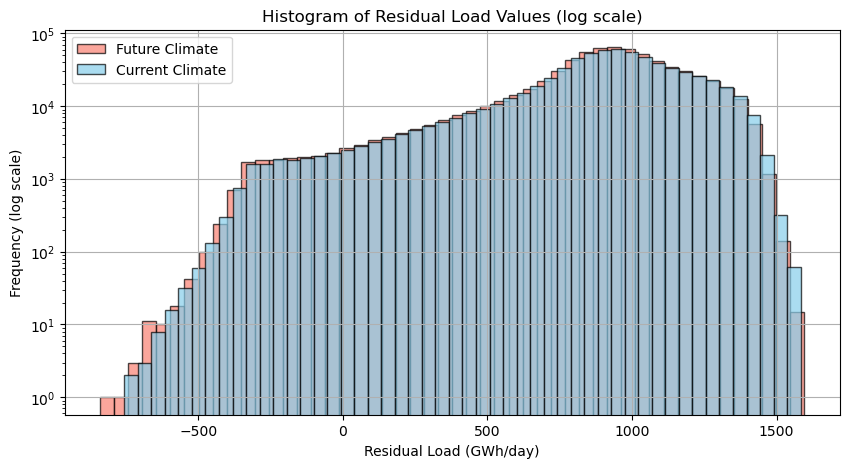

In [29]:
# Compare the distribution of residual load values in the future and current climate
plt.figure(figsize=(10, 5))
plt.hist(res_load_fut.values.flatten(), bins=50, log=True, color='salmon', edgecolor='black', alpha=0.7, label='Future Climate')
plt.hist(res_load_curr_clim.values.flatten(), bins=50, log=True, color='skyblue', edgecolor='black', alpha=0.7, label='Current Climate')
plt.xlabel("Residual Load (GWh/day)")
plt.ylabel("Frequency (log scale)")
plt.title("Histogram of Residual Load Values (log scale)")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# Calculate number of days above a threshold for RL
res_load_thresh = np.quantile(res_load_curr_clim.values.flatten(), 0.95)
wind_off_thresh = np.quantile(wind_off_curr_clim.values.flatten(), 0.05)
wind_on_thresh = np.quantile(wind_on_curr_clim.values.flatten(), 0.05)
wind_thresh = np.quantile(wind_curr_clim.values.flatten(), 0.05)
solar_thresh = np.quantile(solar_curr_clim.values.flatten(), 0.05)
total_thresh = np.quantile(total_curr_clim.values.flatten(), 0.05)
demand_thresh = np.quantile(demand_curr_clim.values.flatten(), 0.95)

RL_days_fut = (res_load_fut > res_load_thresh).sum().item()
RL_days_curr = (res_load_curr_clim > res_load_thresh).sum().item()
wind_off_days_fut = (wind_off_fut < wind_off_thresh).sum().item()
wind_off_days_curr = (wind_off_curr_clim < wind_off_thresh).sum().item()
wind_on_days_fut = (wind_on_fut < wind_on_thresh).sum().item()
wind_on_days_curr = (wind_on_curr_clim < wind_on_thresh).sum().item()
wind_days_fut = (wind_fut < wind_thresh).sum().item()
wind_days_curr = (wind_curr_clim < wind_thresh).sum().item()
solar_days_fut = (solar_fut < solar_thresh).sum().item()
solar_days_curr = (solar_curr_clim < solar_thresh).sum().item()
total_days_fut = (total_fut < total_thresh).sum().item()
total_days_curr = (total_curr_clim < total_thresh).sum().item()
demand_days_fut = (demand_fut > demand_thresh).sum().item()
demand_days_curr = (demand_curr_clim > demand_thresh).sum().item()

# Print results
print(f"Number of days with Residual Load above {res_load_thresh:.2f} GWh/day:")
print(f"Future Climate: {RL_days_fut} days")
print(f"Current Climate: {RL_days_curr} days")
print(f"\nNumber of days with Wind Offshore below {wind_off_thresh:.2f} GWh/day:")
print(f"Future Climate: {wind_off_days_fut} days")
print(f"Current Climate: {wind_off_days_curr} days")
print(f"\nNumber of days with Wind Onshore below {wind_on_thresh:.2f} GWh/day:")
print(f"Future Climate: {wind_on_days_fut} days")
print(f"Current Climate: {wind_on_days_curr} days")
print(f"\nNumber of days with Wind below {wind_thresh:.2f} GWh/day:")
print(f"Future Climate: {wind_days_fut} days")
print(f"Current Climate: {wind_days_curr} days")
print(f"\nNumber of days with Solar below {solar_thresh:.2f} GWh/day:")
print(f"Future Climate: {solar_days_fut} days")
print(f"Current Climate: {solar_days_curr} days")
print(f"\nNumber of days with Total Production below {total_thresh:.2f} GWh/day:")
print(f"Future Climate: {total_days_fut} days")
print(f"Current Climate: {total_days_curr} days")
print(f"\nNumber of days with Demand above {demand_thresh:.2f} GWh/day:")
print(f"Future Climate: {demand_days_fut} days")
print(f"Current Climate: {demand_days_curr} days")



Number of days with Residual Load above 1319.14 GWh/day:
Future Climate: 31667 days
Current Climate: 35223 days

Number of days with Wind Offshore below 2.76 GWh/day:
Future Climate: 36890 days
Current Climate: 35223 days

Number of days with Wind Onshore below 16.23 GWh/day:
Future Climate: 38010 days
Current Climate: 35223 days

Number of days with Wind below 20.60 GWh/day:
Future Climate: 37939 days
Current Climate: 35223 days

Number of days with Solar below 32.53 GWh/day:
Future Climate: 35207 days
Current Climate: 35223 days

Number of days with Total Production below 159.73 GWh/day:
Future Climate: 35334 days
Current Climate: 35223 days

Number of days with Demand above 1527.20 GWh/day:
Future Climate: 24891 days
Current Climate: 35223 days
